In [89]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [90]:
#Configuração inicial dos paramentros
np.random.seed(42)

# Número de dias úteis por ano
dias_por_ano = 252
anos = [2020, 2021, 2022, 2023, 2024]
total_dias = dias_por_ano * len(anos)

# Média anual e volatilidade anual aproximada para cada ativo
params = {
    'IBOV': {'mu': 0.08, 'sigma': 0.25},
    'SP500': {'mu': 0.10, 'sigma': 0.20},
    'USDBRL': {'mu': 0.02, 'sigma': 0.05},
    'OURO': {'mu': 0.06, 'sigma': 0.15},
    'VIX': {'mu': 0.20, 'sigma': 0.10},
    'IPCA': {'mu': 0.04, 'sigma': 0.015}
}

# Criar datas diárias
dates = pd.bdate_range(start='2020-01-02', periods=total_dias)


In [91]:
#geração de dados
df = pd.DataFrame(index=dates)

for ativo in ['IBOV', 'SP500', 'USDBRL', 'OURO']:
    # Converter média e volatilidade anual para diária
    mu_d = params[ativo]['mu'] / dias_por_ano
    sigma_d = params[ativo]['sigma'] / np.sqrt(dias_por_ano)
    
    # Simular log-retornos diários
    ret_diario = np.random.normal(mu_d, sigma_d, total_dias)
    
    # Calcular preços a partir de um valor inicial arbitrário
    preco_inicial = 100
    df[ativo] = preco_inicial * np.exp(np.cumsum(ret_diario))
    df[f'ret_log_{ativo}'] = ret_diario

# VIX e IPCA diários
df['VIX'] = np.random.normal(params['VIX']['mu'], params['VIX']['sigma'], total_dias)
df['IPCA'] = np.random.normal(params['IPCA']['mu']/dias_por_ano, params['IPCA']['sigma']/np.sqrt(dias_por_ano), total_dias)


In [92]:
#Dados para serem usados no modelo
ativos = ['IBOV', 'SP500', 'USDBRL', 'OURO']
lags = 1
features = []

for ativo in ativos:
    df[f'{ativo}_lag1'] = df[f'ret_log_{ativo}'].shift(lags)
    features.append(f'{ativo}_lag1')

df.dropna(inplace=True)

X = df[features]
y = df[[f'ret_log_{ativo}' for ativo in ativos]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

rf_models = {}
y_pred = pd.DataFrame(index=y_test.index)

for ativo in ativos:
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train[f'ret_log_{ativo}'])
    rf_models[ativo] = rf
    y_pred[ativo] = rf.predict(X_test)


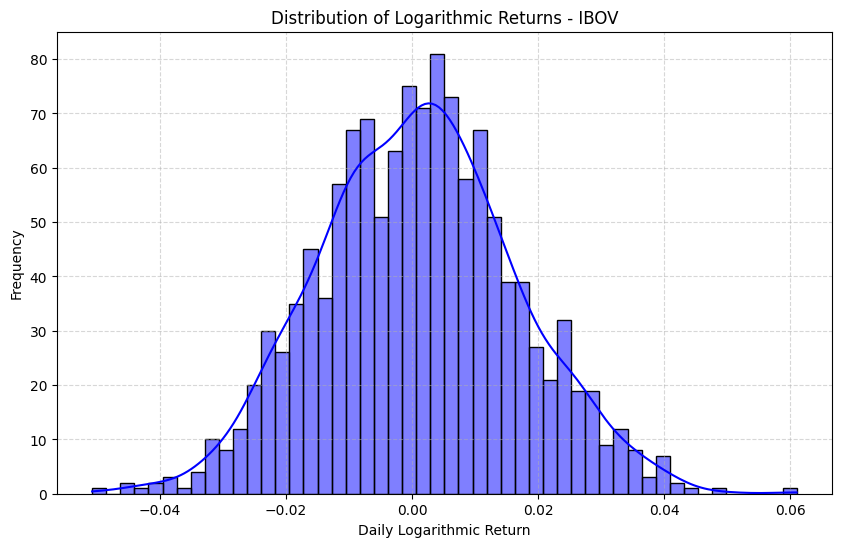

C:\Users\joaop\AppData\Local\Temp\ipykernel_14148\36983760.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['ret_log_IBOV'], label='IBOV', shade=True)
C:\Users\joaop\AppData\Local\Temp\ipykernel_14148\36983760.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['ret_log_SP500'], label='SP500', shade=True)
C:\Users\joaop\AppData\Local\Temp\ipykernel_14148\36983760.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['ret_log_USDBRL'], label='USDBRL', shade=True)
C:\Users\joaop\AppData\Local\Temp\ipykernel_14148\36983760.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`

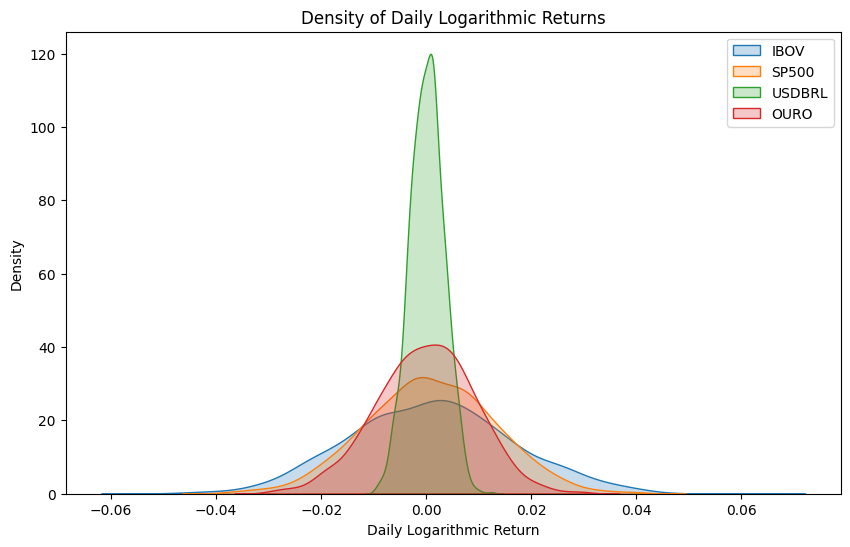

In [ ]:
#Grafico de distribuiçãos dos ativos 

plt.figure(figsize=(10,6))
sns.histplot(df['ret_log_IBOV'], bins=50, kde=True, color='blue')
plt.title('Distribution of Logarithmic Returns - IBOV')
plt.xlabel('Daily Logarithmic Return')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(10,6))
sns.kdeplot(df['ret_log_IBOV'], label='IBOV', shade=True)
sns.kdeplot(df['ret_log_SP500'], label='SP500', shade=True)
sns.kdeplot(df['ret_log_USDBRL'], label='USDBRL', shade=True)
sns.kdeplot(df['ret_log_OURO'], label='OURO', shade=True)
plt.title('Density of Daily Logarithmic Returns')
plt.xlabel('Daily Logarithmic Return')
plt.ylabel('Density')
plt.legend()
plt.show()


In [94]:
#Alocação da carteira
alloc = {
    'IBOV': 0.25,
    'SP500': 0.35,
    'USDBRL': 0.20,
    'OURO': 0.20
}

df['ret_carteira'] = sum(df[f'ret_log_{ativo}'] * alloc[ativo] for ativo in ativos)


In [95]:
#Calculo do risco
tabela_final = pd.DataFrame({
    'Ano': df['Ano'].unique(),
    'Retorno': df.groupby('Ano')['ret_carteira'].mean(),
    'Risco': df.groupby('Ano')['ret_carteira'].std() * np.sqrt(252)
})


KeyError: 'Ano'

In [ ]:
# Função para converter retorno logarítmico para percentual
def ret_to_percent(log_ret):
    return (np.exp(log_ret) - 1) * 100

# Ativos
ativos = ['IBOV', 'SP500', 'USDBRL', 'OURO']

ret_ano = df.groupby('Ano')[[f'ret_log_{ativo}' for ativo in ativos] + ['ret_carteira']].sum()
ret_ano = ret_ano.apply(ret_to_percent)

dias_por_ano = 252
risco_ano = df.groupby('Ano')[['ret_carteira']].std() * np.sqrt(dias_por_ano) * 100


vix_ano = df.groupby('Ano')['VIX'].mean() * 100
ipca_ano = df.groupby('Ano')['IPCA'].sum() * 100
tabela_final = pd.concat([ret_ano, risco_ano, vix_ano, ipca_ano], axis=1)

tabela_final.columns = [*ativos, 'Portfolio', 'Risk_Portfolio', 'VIX', 'IPCA']

tabela_final = tabela_final.round(2)

# Mostrar tabela final em %
print(tabela_final)




        IBOV  SP500  USDBRL   OURO  Portfolio  Risk_Portfolio    VIX  IPCA
Ano                                                                       
2020    9.56  55.90    9.70 -18.47      16.87            9.81  20.21  2.45
2021    7.77  32.48   -4.76 -11.58       8.63            9.84  19.01  2.97
2022   -6.28   1.79    0.52  -6.36      -2.19            9.83  19.52  4.77
2023  106.56   2.73    5.33  -5.06      21.02            9.21  19.73  3.55
2024   37.93  17.61    3.21  19.66      19.65            9.77  19.71  3.30
